In [74]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

In [75]:
data=pd.read_csv('./artifacts/sentiment_analysis.csv')

In [76]:
data.head()

,id,label,tweet
0,1,0,#fingerprint #Pregnancy Test https://goo.gl/h1...
1,2,0,Finally a transparant silicon case ^^ Thanks t...
2,3,0,We love this! Would you go? #talk #makememorie...
3,4,0,I'm wired I know I'm George I was made that wa...
4,5,1,What amazing service! Apple won't even talk to...


In [77]:
data.shape


(7920, 3)

In [78]:
data.duplicated().sum()

np.int64(0)

In [79]:
data.isnull().sum()

id       0
label    0
tweet    0
dtype: int64

In [80]:
import re
import string

In [81]:
data["tweet"] = data["tweet"].apply(lambda x: " ".join(word.lower() for word in x.split()))

In [82]:
data["tweet"].head(5)

0    #fingerprint #pregnancy test https://goo.gl/h1...
1    finally a transparant silicon case ^^ thanks t...
2    we love this! would you go? #talk #makememorie...
3    i'm wired i know i'm george i was made that wa...
4    what amazing service! apple won't even talk to...
Name: tweet, dtype: str

In [83]:
data["tweet"] = data["tweet"].apply(lambda x: re.sub(r"http\S+|www\S+", " ", x))

In [84]:
data["tweet"].head(5)

0    #fingerprint #pregnancy test   #android #apps ...
1    finally a transparant silicon case ^^ thanks t...
2    we love this! would you go? #talk #makememorie...
3    i'm wired i know i'm george i was made that wa...
4    what amazing service! apple won't even talk to...
Name: tweet, dtype: str

In [85]:
data["tweet"] = data["tweet"].apply(lambda x: re.sub(r"[^a-z\s]", " ", x))

In [86]:
data["tweet"].head(5)

0     fingerprint  pregnancy test    android  apps ...
1    finally a transparant silicon case    thanks t...
2    we love this  would you go   talk  makememorie...
3    i m wired i know i m george i was made that wa...
4    what amazing service  apple won t even talk to...
Name: tweet, dtype: str

In [87]:
data["tweet"].tail(10)

7910    perfect match  instagood  applewatch  red  ins...
7911    i am completely in love with the new iphone em...
7912    tune in  turn on  drop out     gtd in one app ...
7913    ok so my galaxy crashed after one day now i ha...
7914    gain followers rt this must follow me i follow...
7915    live out loud  lol  liveoutloud  selfie  smile...
7916    we would like to wish you an amazing day  make...
7917    helping my lovely    year old neighbor with he...
7918    finally got my  smart  pocket  wifi stay conne...
7919    apple barcelona     apple  store  bcn  barcelo...
Name: tweet, dtype: str

In [88]:
import nltk

In [89]:
nltk.download('stopwords',download_dir='./static/model')

[nltk_data] Downloading package stopwords to ./static/model...
[nltk_data]   Package stopwords is already up-to-date!


True

In [90]:
with open('./static/model/corpora/stopwords/english','r') as file:
    sw=file.read().splitlines()

In [91]:
sw

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [92]:
# remove stopwords, keep spacing
data["tweet"] = data["tweet"].apply(
    lambda x: " ".join(word for word in x.split() if word not in sw)
)

In [93]:
data["tweet"].head(5)

0    fingerprint pregnancy test android apps beauti...
1    finally transparant silicon case thanks uncle ...
2    love would go talk makememories unplug relax i...
3    wired know george made way iphone cute daventr...
4    amazing service apple even talk question unles...
Name: tweet, dtype: str

In [94]:
from nltk.stem import PorterStemmer
ps=PorterStemmer()

In [95]:
data["tweet"] = data["tweet"].apply(lambda x: " ".join(ps.stem(x) for x in x.split()))

In [96]:
data["tweet"].head(5)

0    fingerprint pregnanc test android app beauti c...
1    final transpar silicon case thank uncl yay son...
2    love would go talk makememori unplug relax iph...
3    wire know georg made way iphon cute daventri home
4    amaz servic appl even talk question unless pay...
Name: tweet, dtype: str

In [97]:
data

,id,label,tweet
0,1,0,fingerprint pregnanc test android app beauti c...
1,2,0,final transpar silicon case thank uncl yay son...
2,3,0,love would go talk makememori unplug relax iph...
3,4,0,wire know georg made way iphon cute daventri home
4,5,1,amaz servic appl even talk question unless pay...
...,...,...,...
7915,7916,0,live loud lol liveoutloud selfi smile soni mus...
7916,7917,0,would like wish amaz day make everi minut coun...
7917,7918,0,help love year old neighbor ipad morn made rea...
7918,7919,0,final got smart pocket wifi stay connect anyti...


In [98]:
from collections import Counter
vocab=Counter()

In [99]:
vocab

Counter()

In [100]:
for sentence in data["tweet"]:
    vocab.update(sentence.split())

In [101]:
vocab

Counter({'iphon': 4274,
         'appl': 2925,
         'samsung': 1434,
         'new': 1149,
         'twitter': 1115,
         'com': 1044,
         'phone': 1040,
         'follow': 935,
         'soni': 854,
         'pic': 629,
         'like': 558,
         'ipad': 541,
         'rt': 536,
         'love': 508,
         'day': 443,
         'android': 422,
         'life': 422,
         'app': 421,
         'io': 404,
         'photo': 397,
         'get': 384,
         'galaxi': 377,
         'instagram': 374,
         'case': 359,
         'beauti': 332,
         'cute': 332,
         'work': 314,
         'today': 314,
         'gain': 312,
         'happi': 302,
         'back': 298,
         'photographi': 297,
         'fuck': 294,
         'game': 287,
         'fun': 283,
         'got': 281,
         'thank': 268,
         'music': 268,
         'news': 266,
         'time': 253,
         'instagood': 251,
         'make': 247,
         'updat': 241,
         'smile': 2

In [102]:
len(vocab)

15327

In [103]:
tokens=[key for key in vocab if vocab[key]>10]

In [104]:
len(tokens)

1157

In [105]:
def save_vocabulary(lines,filename):
    data='\n'.join(lines)
    file=open(filename,'w',encoding="utf-8")
    file.write(data)
    file.close()
save_vocabulary(tokens,'./static/model/vocabulary.txt')

In [106]:
x=data["tweet"]
y=data["label"]

In [107]:
y

0       0
1       0
2       0
3       0
4       1
       ..
7915    0
7916    0
7917    0
7918    0
7919    0
Name: label, Length: 7920, dtype: int64

In [108]:
!pip install scikit-learn

In [109]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [110]:
x_train.shape

(6336,)

In [111]:
x_test.shape

(1584,)

In [112]:
##vectorization

In [113]:
def vectorizer(ds,vocabulary):
    vectorized_list=[]
    for sentence in ds:
        sentence_list=np.zeros(len(vocabulary))

        for i in range(len(vocabulary)):
            if vocabulary[i] in sentence.split():
                sentence_list[i]=1

        vectorized_list.append(sentence_list)

    vectorized_list_new=np.asarray(vectorized_list,dtype=np.float32)
    return vectorized_list_new

In [114]:
vectorized_x_train=vectorizer(x_train,tokens)

In [115]:
vectorized_x_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(6336, 1157), dtype=float32)

In [116]:
vectorized_x_test=vectorizer(x_test,tokens)

In [117]:
vectorized_x_test

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(1584, 1157), dtype=float32)

In [118]:
y_train.value_counts()

label
0    4720
1    1616
Name: count, dtype: int64

In [119]:
##handle imbalanced dataset

In [120]:
!pip install imbalanced.learn

In [121]:
from imblearn.over_sampling import SMOTE
smote=SMOTE()
vectorized_x_train_smote,y_train_smote = smote.fit_resample(vectorized_x_train,y_train)
print(vectorized_x_train_smote.shape,y_train_smote.shape)

(9440, 1157) (9440,)


In [122]:
y_train_smote.value_counts()

label
0    4720
1    4720
Name: count, dtype: int64

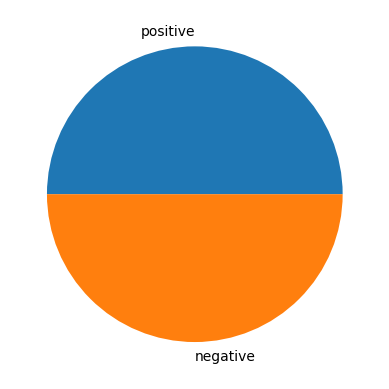

In [123]:
plt.pie(np.array([y_train_smote.value_counts()[0],y_train_smote.value_counts()[1]]),labels=['positive','negative'])
plt.show()

In [124]:
vectorized_x_train_smote

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(9440, 1157), dtype=float32)

In [125]:
y_train_smote

0       0
1       0
2       0
3       0
4       0
       ..
9435    1
9436    1
9437    1
9438    1
9439    1
Name: label, Length: 9440, dtype: int64

In [126]:
vectorized_x_test

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(1584, 1157), dtype=float32)

In [127]:
y_test

408     0
2780    1
6917    0
3166    0
6637    1
       ..
6723    1
6102    0
2075    0
5309    1
52      0
Name: label, Length: 1584, dtype: int64

In [128]:
##model training and evaluation

In [129]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [130]:
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score

def training_scores(y_act,y_pred):
    acc=round(accuracy_score(y_act,y_pred),3)
    pr=round(precision_score(y_act,y_pred),3)
    rec=round(recall_score(y_act,y_pred),3)
    f1=round(f1_score(y_act,y_pred),3)
    print(f'Training Scores:\n\tAccuracy ={acc}\n\tPrecision ={pr}\n\tRecall={rec}\n\tF1-Score={f1}')

def validation_scores(y_act,y_pred):
    acc=round(accuracy_score(y_act,y_pred),3)
    pr=round(precision_score(y_act,y_pred),3)
    rec=round(recall_score(y_act,y_pred),3)
    f1=round(f1_score(y_act,y_pred),3)
    print(f'Testing Scores:\n\tAccuracy ={acc}\n\tPrecision ={pr}\n\tRecall={rec}\n\tF1-Score={f1}')

In [131]:
##Logistic Regression

In [132]:
lr=LogisticRegression()
lr.fit(vectorized_x_train_smote,y_train_smote)
y_train_pred=lr.predict(vectorized_x_train_smote)
y_test_pred=lr.predict(vectorized_x_test)

training_scores(y_train_smote,y_train_pred)
validation_scores(y_test,y_test_pred)

Training Scores:
	Accuracy =0.943
	Precision =0.92
	Recall=0.97
	F1-Score=0.944
Testing Scores:
	Accuracy =0.875
	Precision =0.717
	Recall=0.854
	F1-Score=0.78


In [133]:
y_train_pred

array([1, 0, 1, ..., 1, 1, 1], shape=(9440,))

In [134]:
y_train_smote

0       0
1       0
2       0
3       0
4       0
       ..
9435    1
9436    1
9437    1
9438    1
9439    1
Name: label, Length: 9440, dtype: int64

In [135]:
y_test_pred

array([0, 1, 0, ..., 0, 1, 0], shape=(1584,))

In [136]:
y_test

408     0
2780    1
6917    0
3166    0
6637    1
       ..
6723    1
6102    0
2075    0
5309    1
52      0
Name: label, Length: 1584, dtype: int64

In [137]:
##Naive Bayes

In [138]:
mnb=MultinomialNB()
mnb.fit(vectorized_x_train_smote,y_train_smote)
y_train_pred=mnb.predict(vectorized_x_train_smote)
y_test_pred=mnb.predict(vectorized_x_test)

training_scores(y_train_smote,y_train_pred)
validation_scores(y_test,y_test_pred)

Training Scores:
	Accuracy =0.906
	Precision =0.871
	Recall=0.954
	F1-Score=0.911
Testing Scores:
	Accuracy =0.875
	Precision =0.698
	Recall=0.912
	F1-Score=0.791


In [139]:
##Decision Tree

In [140]:
dt=DecisionTreeClassifier()
dt.fit(vectorized_x_train_smote,y_train_smote)
y_train_pred=dt.predict(vectorized_x_train_smote)
y_test_pred=dt.predict(vectorized_x_test)

training_scores(y_train_smote,y_train_pred)
validation_scores(y_test,y_test_pred)

Training Scores:
	Accuracy =1.0
	Precision =1.0
	Recall=1.0
	F1-Score=1.0
Testing Scores:
	Accuracy =0.833
	Precision =0.682
	Recall=0.666
	F1-Score=0.674


In [141]:
##Random Forest

In [142]:
rf=RandomForestClassifier()
rf.fit(vectorized_x_train_smote,y_train_smote)
y_train_pred=rf.predict(vectorized_x_train_smote)
y_test_pred=rf.predict(vectorized_x_test)

training_scores(y_train_smote,y_train_pred)
validation_scores(y_test,y_test_pred)

Training Scores:
	Accuracy =1.0
	Precision =1.0
	Recall=1.0
	F1-Score=1.0
Testing Scores:
	Accuracy =0.86
	Precision =0.749
	Recall=0.693
	F1-Score=0.72


In [143]:
##SVM

In [144]:
svm=SVC()
svm.fit(vectorized_x_train_smote,y_train_smote)
y_train_pred=svm.predict(vectorized_x_train_smote)
y_test_pred=svm.predict(vectorized_x_test)

training_scores(y_train_smote,y_train_pred)
validation_scores(y_test,y_test_pred)

Training Scores:
	Accuracy =0.979
	Precision =0.962
	Recall=0.998
	F1-Score=0.98
Testing Scores:
	Accuracy =0.884
	Precision =0.756
	Recall=0.817
	F1-Score=0.785


In [145]:
import pickle
with open('./static/model/model.pickle','wb') as file:
    pickle.dump(lr,file)